<a href="https://colab.research.google.com/github/joaossmacedo/SoccerAnalysis/blob/main/notebooks/analysis/general/xg/overperformance/2025_07_07_xg_overperformance_over_age.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
# !python3 -m pip install soccerdata
# import soccerdata as sd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 100)

# Params

In [3]:
path_shots = '/content/drive/My Drive/database/soccerdata/fbref/raw_clean/shot_events/database.csv'
path_player_matches = '/content/drive/My Drive/database/soccerdata/fbref/raw_clean/player_match_stats/summary/database.csv'

In [4]:
season = [
  f'{i}{i+1}' for i in range(17, 25)
]

# Code

## Prepare Colab

In [5]:
from google.colab import drive
import os

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Getting data

In [6]:
df_shots = pd.read_csv(path_shots)
df_shots.head(2)

,league,season,game,minute,player,team,xG,PSxG,outcome,distance,body_part,notes,SCA 1_player,SCA 1_event,SCA 2_player,SCA 2_event,is_volley,is_freekick,is_deflected,game_date,game_team_h,game_team_a
0,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,2,Alexandre Lacazette,Arsenal,0.06,0.37,Goal,13,Head,NaN,Mohamed Elneny,Pass (Live),Héctor Bellerín,Pass (Live),0,0,0,2017-08-11,Arsenal,Leicester City
1,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,4,Riyad Mahrez,Leicester City,0.08,NaN,Off Target,17,Left Foot,NaN,NaN,NaN,NaN,NaN,0,0,0,2017-08-11,Arsenal,Leicester City


In [7]:
df_player_matches = pd.read_csv(path_player_matches)
df_player_matches.head(2)

,league,season,game,team,player,jersey_number,nation,age,min,Performance_Gls,Performance_Ast,Performance_PK,Performance_PKatt,Performance_Sh,Performance_SoT,Performance_CrdY,Performance_CrdR,Performance_Touches,Performance_Tkl,Performance_Int,Performance_Blocks,Expected_xG,Expected_npxG,Expected_xAG,SCA_SCA,SCA_GCA,Passes_Cmp,Passes_Att,Passes_Cmp%,Passes_PrgP,Carries_Carries,Carries_PrgC,Take-Ons_Att,Take-Ons_Succ,game_id,pos_GK,pos_DF,pos_CB,pos_RB,pos_LB,pos_WB,pos_DM,pos_CM,pos_MF,pos_LW,pos_LM,pos_AM,pos_RM,pos_RW,pos_FW,game_date,game_team_h,game_team_a
0,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,Arsenal,Aaron Ramsey,8,WAL,26-228,24.0,1,0,0,0,4,1,0,0,19.0,0.0,0,0.0,0.4,0.4,0.0,1.0,0.0,9.0,12.0,75.0,1.0,13.0,0.0,0.0,0.0,e3c3ddf0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,2017-08-11,Arsenal,Leicester City
1,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,Arsenal,Alex Oxlade-Chamberlain,15,ENG,23-361,90.0,0,0,0,0,6,2,0,0,84.0,3.0,3,1.0,0.2,0.2,0.1,4.0,0.0,48.0,67.0,71.6,6.0,54.0,9.0,9.0,8.0,e3c3ddf0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,2017-08-11,Arsenal,Leicester City


## Cleaning data

In [8]:
df_shots = df_shots[~df_shots['player'].str.endswith('(pen)')]
df_shots['goal'] = (df_shots['outcome'] == 'Goal').astype('int')
df_shots['PSxG'] = df_shots['PSxG'].fillna(0)
df_shots.head(1)

/tmp/ipython-input-8-3479065225.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots['goal'] = (df_shots['outcome'] == 'Goal').astype('int')
/tmp/ipython-input-8-3479065225.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots['PSxG'] = df_shots['PSxG'].fillna(0)


,league,season,game,minute,player,team,xG,PSxG,outcome,distance,body_part,notes,SCA 1_player,SCA 1_event,SCA 2_player,SCA 2_event,is_volley,is_freekick,is_deflected,game_date,game_team_h,game_team_a,goal
0,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,2,Alexandre Lacazette,Arsenal,0.06,0.37,Goal,13,Head,NaN,Mohamed Elneny,Pass (Live),Héctor Bellerín,Pass (Live),0,0,0,2017-08-11,Arsenal,Leicester City,1


## Filtering games

In [9]:
if season is not None:
  df_player_matches = df_player_matches[df_player_matches['season'].astype('str').isin(season)]
  print(len(df_player_matches))

len(df_player_matches)

423788


423788

In [10]:
df_player_matches.head(1)

,league,season,game,team,player,jersey_number,nation,age,min,Performance_Gls,Performance_Ast,Performance_PK,Performance_PKatt,Performance_Sh,Performance_SoT,Performance_CrdY,Performance_CrdR,Performance_Touches,Performance_Tkl,Performance_Int,Performance_Blocks,Expected_xG,Expected_npxG,Expected_xAG,SCA_SCA,SCA_GCA,Passes_Cmp,Passes_Att,Passes_Cmp%,Passes_PrgP,Carries_Carries,Carries_PrgC,Take-Ons_Att,Take-Ons_Succ,game_id,pos_GK,pos_DF,pos_CB,pos_RB,pos_LB,pos_WB,pos_DM,pos_CM,pos_MF,pos_LW,pos_LM,pos_AM,pos_RM,pos_RW,pos_FW,game_date,game_team_h,game_team_a
0,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,Arsenal,Aaron Ramsey,8,WAL,26-228,24.0,1,0,0,0,4,1,0,0,19.0,0.0,0,0.0,0.4,0.4,0.0,1.0,0.0,9.0,12.0,75.0,1.0,13.0,0.0,0.0,0.0,e3c3ddf0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,2017-08-11,Arsenal,Leicester City


## Joining data

In [11]:
df_player_matches = df_player_matches[['game', 'team', 'player', 'age'] + [c for c in df_player_matches.columns if c.startswith('pos_')]]

df_player_shots = df_shots.merge(
  df_player_matches, on=['game', 'player'], how='left'
)
print(len(df_player_shots))
df_player_shots.head(1)

438384


,league,season,game,minute,player,team_x,xG,PSxG,outcome,distance,body_part,notes,SCA 1_player,SCA 1_event,SCA 2_player,SCA 2_event,is_volley,is_freekick,is_deflected,game_date,game_team_h,game_team_a,goal,team_y,age,pos_GK,pos_DF,pos_CB,pos_RB,pos_LB,pos_WB,pos_DM,pos_CM,pos_MF,pos_LW,pos_LM,pos_AM,pos_RM,pos_RW,pos_FW
0,ENG-Premier League,1718,2017-08-11 Arsenal-Leicester City,2,Alexandre Lacazette,Arsenal,0.06,0.37,Goal,13,Head,NaN,Mohamed Elneny,Pass (Live),Héctor Bellerín,Pass (Live),0,0,0,2017-08-11,Arsenal,Leicester City,1,Arsenal,26-075,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1


## Filtering teams

In [12]:
_map = {
  'Brighton and Hove Albion': 'Brighton & Hove Albion',
  'Brighton': 'Brighton & Hove Albion',
  'Inter': 'Internazionale',
  'Betis': 'Real Betis',
  'Eint Frankfurt': 'Eintracht Frankfurt',
  'Gladbach': 'Mönchengladbach',
  'Huddersfield': 'Huddersfield Town',
  'La Coruña': 'Deportivo La Coruña',
  'Leverkusen': 'Bayer Leverkusen',
  'Manchester Utd': 'Manchester United',
  'Newcastle Utd': 'Newcastle United',
  "Nott'ham Forest": 'Nottingham Forest',
  'Paris S-G': 'Paris Saint-Germain',
  'Sheffield Utd': 'Sheffield United',
  'Tottenham': 'Tottenham Hotspur',
  'West Brom': 'West Bromwich Albion',
  'West Ham': 'West Ham United',
  'Wolves': 'Wolverhampton Wanderers',
}

In [13]:
# prompt: replace values in pandas

df_player_shots['team_x'] = df_player_shots['team_x'].replace(_map)
df_player_shots['team_y'] = df_player_shots['team_y'].replace(_map)

In [14]:
len(df_player_shots[df_player_shots['team_x'] != df_player_shots['team_y']])

14

In [15]:
df_player_shots = df_player_shots[df_player_shots['team_x'] == df_player_shots['team_y']]

## Grouping data by age

In [16]:
import numpy as np
df_player_shots['age_years'] = df_player_shots['age'].str.split('-').str[0]
df_player_shots['age_years'] = pd.to_numeric(df_player_shots['age_years'], errors='coerce')
df_player_shots['age_years'] = np.clip(df_player_shots['age_years'], 18, 38)
df_player_shots['count'] = 1

df_grouped = df_player_shots.groupby(['age_years'],observed=True).agg({
    'count': 'count', 'goal': 'sum', 'PSxG': 'sum', 'xG': 'sum'
})

df_grouped['g / xg'] = (df_grouped['goal'] / df_grouped['xG']).apply(lambda x: f"{x:.2%}")
df_grouped['psxg / xg'] = (df_grouped['PSxG'] / df_grouped['xG']).apply(lambda x: f"{x:.2%}")

df_grouped['PSxG'] = df_grouped['PSxG'].astype('int')
df_grouped['xG'] = df_grouped['xG'].astype('int')


df_grouped.reset_index().sort_values(['age_years'])

,age_years,count,goal,PSxG,xG,g / xg,psxg / xg
0,18.0,5033,523,477,519,100.64%,91.96%
1,19.0,8071,786,799,823,95.40%,97.05%
2,20.0,15932,1569,1591,1673,93.75%,95.08%
3,21.0,23405,2352,2258,2339,100.52%,96.54%
4,22.0,31696,3083,3075,3215,95.89%,95.66%
5,23.0,39802,3908,3861,4073,95.93%,94.79%
6,24.0,41367,4052,3943,4202,96.43%,93.86%
7,25.0,41274,4155,4037,4151,100.09%,97.26%
8,26.0,40582,3937,3821,4018,97.98%,95.10%
9,27.0,37996,3758,3666,3903,96.28%,93.94%


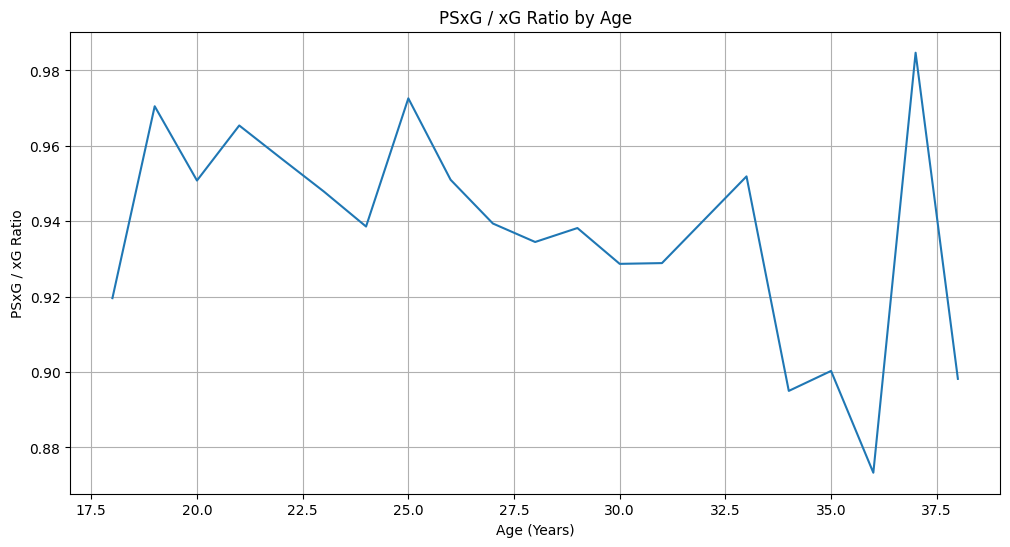

In [17]:
df_grouped['psxg / xg_numeric'] = df_grouped['psxg / xg'].str.rstrip('%').astype('float') / 100.0

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='age_years', y='psxg / xg_numeric')
plt.title('PSxG / xG Ratio by Age')
plt.xlabel('Age (Years)')
plt.ylabel('PSxG / xG Ratio')
plt.grid(True)
plt.show()

/tmp/ipython-input-18-4263877245.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_player_shots_fw['age_years'] = np.clip(df_player_shots['age_years'], 18, 38)


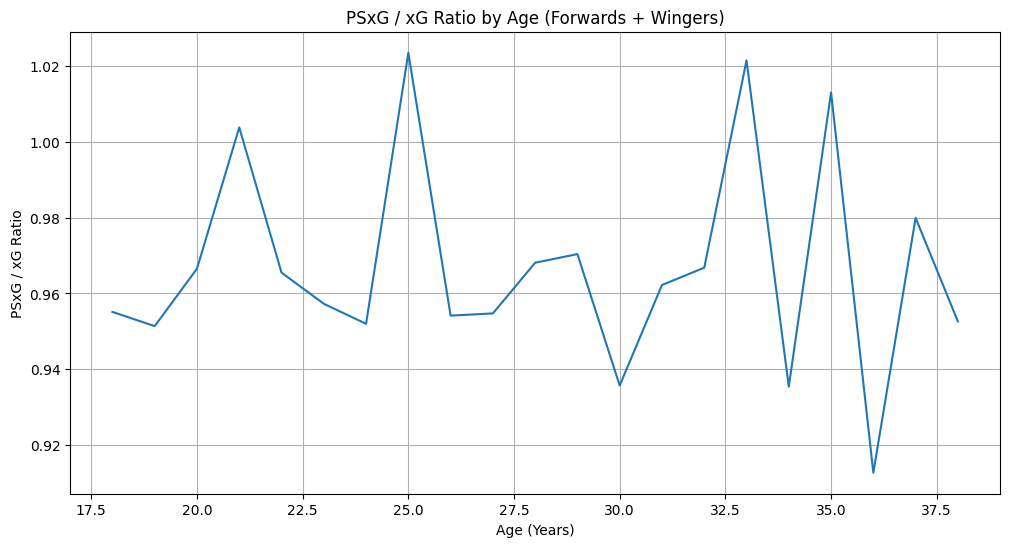

In [18]:
df_player_shots_fw = df_player_shots[(df_player_shots['pos_FW'] + df_player_shots['pos_LW'] + df_player_shots['pos_RW']) >= 1]
df_player_shots_fw['age_years'] = np.clip(df_player_shots['age_years'], 18, 38)

df_grouped = df_player_shots_fw.groupby(['age_years'],observed=True).agg({
    'count': 'count', 'goal': 'sum', 'PSxG': 'sum', 'xG': 'sum'
})

df_grouped['g / xg'] = (df_grouped['goal'] / df_grouped['xG']).apply(lambda x: f"{x:.2%}")
df_grouped['psxg / xg_numeric'] = (df_grouped['PSxG'] / df_grouped['xG'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='age_years', y='psxg / xg_numeric')
plt.title('PSxG / xG Ratio by Age (Forwards + Wingers)')
plt.xlabel('Age (Years)')
plt.ylabel('PSxG / xG Ratio')
plt.grid(True)
plt.show()


/tmp/ipython-input-19-1086599258.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_player_shots_fw['age_years'] = np.clip(df_player_shots['age_years'], 18, 38)


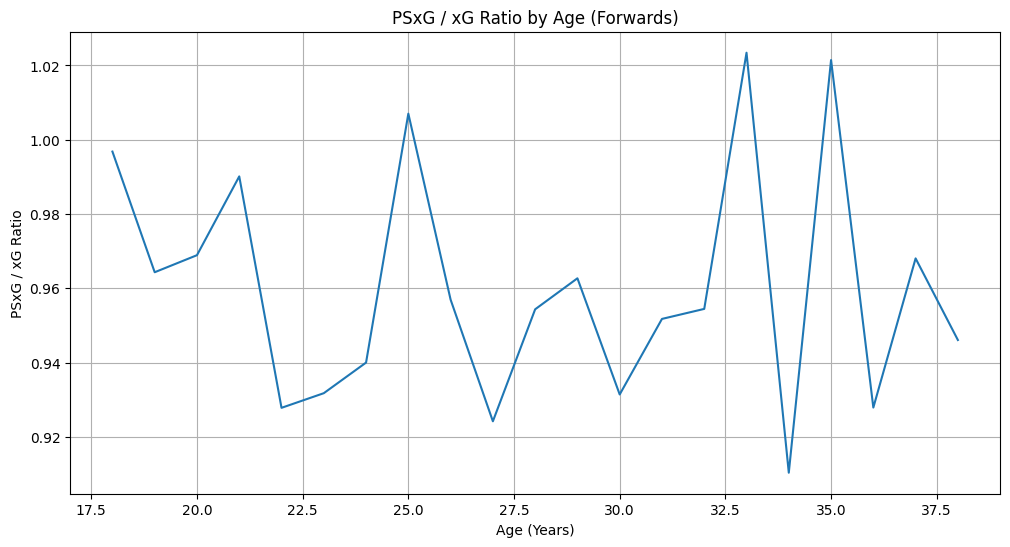

In [19]:
df_player_shots_fw = df_player_shots[df_player_shots['pos_FW'] >= 1]
df_player_shots_fw['age_years'] = np.clip(df_player_shots['age_years'], 18, 38)

df_grouped = df_player_shots_fw.groupby(['age_years'],observed=True).agg({
    'count': 'count', 'goal': 'sum', 'PSxG': 'sum', 'xG': 'sum'
})

df_grouped['g / xg'] = (df_grouped['goal'] / df_grouped['xG']).apply(lambda x: f"{x:.2%}")
df_grouped['psxg / xg_numeric'] = (df_grouped['PSxG'] / df_grouped['xG'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='age_years', y='psxg / xg_numeric')
plt.title('PSxG / xG Ratio by Age (Forwards)')
plt.xlabel('Age (Years)')
plt.ylabel('PSxG / xG Ratio')
plt.grid(True)
plt.show()